In [20]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 10
N = 10_000
rng = np.random.default_rng(SEED)

In [50]:
# Uniform
UNIFORM_LOW, UNIFORM_HIGH = 0, 1000

# Normal
NORMAL_MEAN, NORMAL_STD = 500, 100

# Log-Normal (parameters are for the underlying normal)
LOGNORM_MEAN, LOGNORM_STD = 4.0, 0.8   # exp(mean) ~ 55 will be center

# Zipfian — a controls skew. lower = heavier tail
# 1.2 = very heavy (realistic web/query workloads)
# 2.0 = moderate skew
ZIPF_A = 1.5
ZIPF_CLIP = 200   # clip extreme outliers for readability

# Poisson
POISSON_LAMBDA = 5.0

# Clustered
CLUSTER_N      = 5       # number of cluster centers
CLUSTER_SPREAD = 30      # std dev around each center
CLUSTER_DOMAIN = (0, 1000)

In [51]:
uniform_samples = rng.integers(UNIFORM_LOW, UNIFORM_HIGH, N)

normal_samples = rng.normal(NORMAL_MEAN, NORMAL_STD, N).astype(int)

lognorm_samples = rng.lognormal(LOGNORM_MEAN, LOGNORM_STD, N).astype(int)

# numpy zipf requires a > 1
zipf_samples = rng.zipf(ZIPF_A, N)
zipf_samples = zipf_samples[zipf_samples <= ZIPF_CLIP]   # remove extreme tail for plot

poisson_samples = rng.poisson(POISSON_LAMBDA, N)

# Clustered: pick random centers, then sample normally around each
centers = rng.integers(*CLUSTER_DOMAIN, CLUSTER_N)
chosen  = rng.choice(centers, N)
clustered_samples = (chosen + rng.normal(0, CLUSTER_SPREAD, N)).astype(int)
clustered_samples = np.clip(clustered_samples, *CLUSTER_DOMAIN)

print("Sample counts (after clipping):")
for name, s in [("Uniform", uniform_samples), ("Normal", normal_samples),
                ("LogNormal", lognorm_samples), ("Zipfian", zipf_samples),
                ("Poisson", poisson_samples), ("Clustered", clustered_samples)]:
    print(f"  {name:12s}: {len(s):>6,}  mean={np.mean(s):.1f}  median={np.median(s):.1f}  max={np.max(s)}")

Sample counts (after clipping):
  Uniform     : 10,000  mean=500.5  median=501.0  max=999
  Normal      : 10,000  mean=500.9  median=502.0  max=912
  LogNormal   : 10,000  mean=74.5  median=53.0  max=1589
  Zipfian     :  9,516  mean=11.3  median=2.0  max=200
  Poisson     : 10,000  mean=5.0  median=5.0  max=16
  Clustered   : 10,000  mean=565.6  median=617.0  max=935


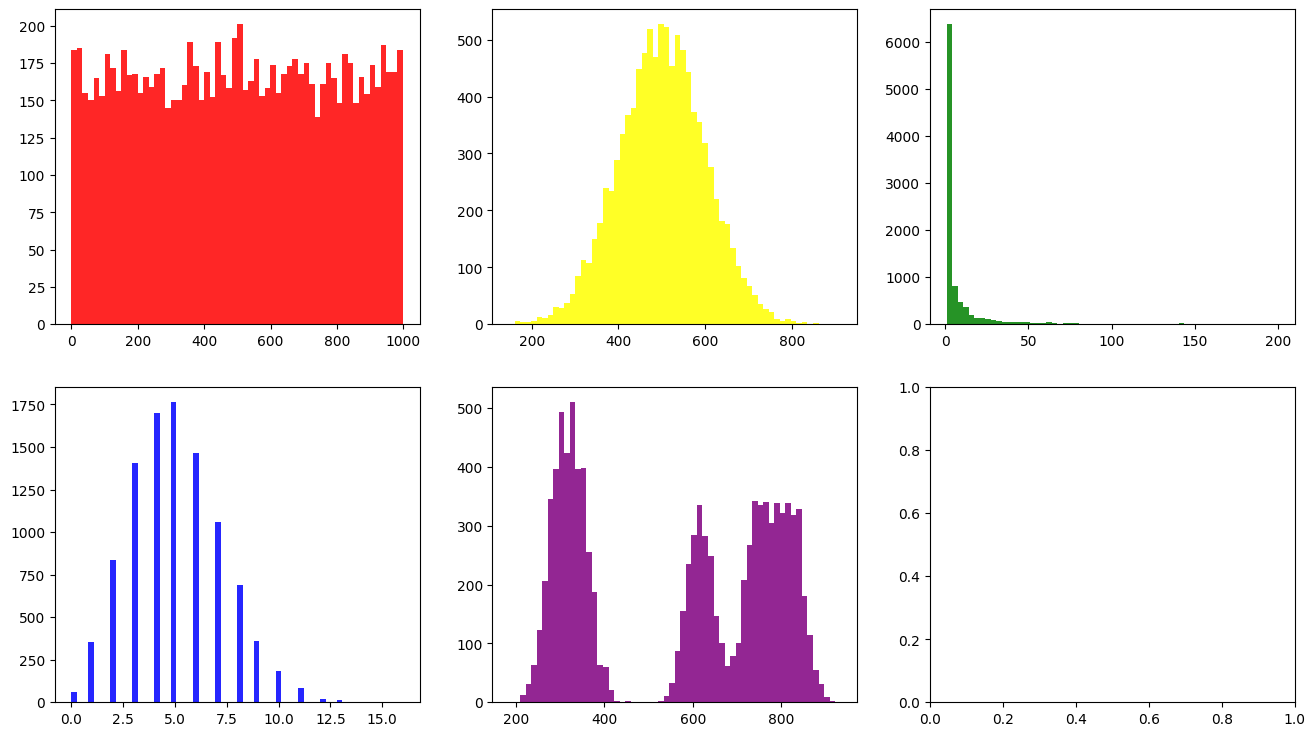

In [57]:
COLORS = ["red", "yellow", "green", "blue", "purple", "brown"]

distributions = [
    ("Uniform",   uniform_samples,   f"Low={UNIFORM_LOW}, High={UNIFORM_HIGH}\nEvery value equally likely"),
    ("Normal",    normal_samples,    f"μ={NORMAL_MEAN}, σ={NORMAL_STD}\nBell curve around mean"),
    ("Zipfian",   zipf_samples,      f"a={ZIPF_A}, clipped at {ZIPF_CLIP}\nFew values dominate — most realistic for DB"),
    ("Poisson",   poisson_samples,   f"λ={POISSON_LAMBDA}\nEvent counts per unit time"),
    ("Clustered", clustered_samples, f"{CLUSTER_N} clusters, spread={CLUSTER_SPREAD}\nDense regions with gaps between them"),
]

fig, axes = plt.subplots(2, 3, figsize=(16,9))
axes = axes.flatten()

for ax, (name, samples, desc), color in zip(axes, distributions, COLORS):
    ax.hist(samples, bins=60, color=color, alpha=0.85, edgecolor="none")

    

In [59]:
from enum import Enum
from dataclasses import dataclass, field
class DataDistribution(Enum):
    UNIFORM     = 1
    NORMAL      = 2
    LOGNORMAL   = 3
    ZIPFIAN     = 4
    POISSON     = 5
    CLUSTERED   = 6
    
@dataclass
class DistributionConfig:
    distribution: DataDistribution = DataDistribution.UNIFORM
    
    # normal
    mean: float = None
    std: float = None

    # zipfian
    zipf_a: float = 1.5

    # poisson
    lam:float = 5.0

    # clustered
    n_clusters: int = 5
    cluster_spread = 0.1

In [61]:
def _sample_width(self, rng, cfg: DistributionConfig) -> int:
    if cfg.width_dist == FIXED:
        return cfg.width_fixed
    if cfg.width_dist == ZIPFIAN:
        return max(1, int(rng.zipf(cfg.zipf_a)))
    if cfg.width_dist == UNIFORM:
        return rng.integers(cfg.width_min, cfg.width_max)

def _sample_position(self, rng, cfg: DistributionConfig) -> int:
    if cfg.pos_dist == UNIFORM:
        return rng.integers(cfg.domain_min, cfg.domain_max)

# def __generate_range(self, experiment: ExperimentSettings) -> RangeType:
#     if np.random.random() < experiment.uncertain_ratio * 0.5:
#         return RangeType(0, 0, True)
#     cfg = experiment.distribution_config
#     lb    = self._sample_position(self.rng, cfg)
#     width = self._sample_width(self.rng, cfg)
#     return RangeType(lb, lb + width)

def generate_range_ex(cfg, ):
    # if np.random.random() < experiment.uncertain_ratio * 0.5:
    #     return RangeType(0, 0, True)
    # cfg = experiment.distribution_config
    
    lb    = self._sample_position(self.rng, cfg)
    width = self._sample_width(self.rng, cfg)
    return RangeType(lb, lb + width)

In [65]:
def generate_intervals2(sampler, n=7):
    """Generate (lb, ub) pairs using sampler for lb, then sample width on top."""
    intervals = []
    for _ in range(n):
        lb = int(np.clip(sampler(), 0, 900))
        # width = 
        width = int(np.clip(sampler(), 1, 200))
        # width = 0
        intervals.append((lb, lb + width))
    return intervals

interval_sets = {
    "Uniform":   generate_intervals2(lambda: rng.integers(0, 1000)),
    "Normal":    generate_intervals2(lambda: rng.normal(500, 150)),
    "Zipfian":   generate_intervals2(lambda: rng.zipf(1.5) * 10),
    "Clustered": generate_intervals2(lambda: rng.choice(centers) + rng.normal(0, 30)),
}

def generate_range_in(interval_size_range= (1, 1000), n=7):
        # # uncertain ratio. maybe should account for half nulls, half mult 0
        # if np.random.random() < experiment.uncertain_ratio * 0.5:  
        #     return RangeType(0, 0, True)

    intervals = []
    for _ in range(n):
        lb = np.random.randint(*interval_size_range)
        ub = np.random.randint(lb+1, interval_size_range[1]+1)

        # protect against mistakes or future changes
        if lb > ub:
            lb, ub = ub, lb
        # return (lb, ub)
        intervals.append((lb, ub))
    return intervals

for d, s in interval_sets.items():
    print(d)
    print(s)

print("Internal")
a = generate_range_in()
print(a)

Uniform
[(279, 479), (865, 914), (547, 747), (752, 952), (523, 723), (26, 226), (900, 1100)]
Normal
[(648, 840), (379, 553), (632, 807), (559, 759), (489, 689), (365, 565), (762, 927)]
Zipfian
[(10, 40), (90, 100), (310, 510), (10, 20), (10, 60), (60, 170), (20, 220)]
Clustered
[(592, 792), (348, 548), (312, 512), (337, 537), (755, 955), (643, 843), (317, 517)]
Internal
[(879, 886), (57, 508), (228, 596), (751, 822), (42, 728), (963, 977), (926, 992)]


import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
N = 10_000
RANGE = (1, 1000)

# Current approach 
# ub is sampled from [lb+1, max], so width = ub - lb 
lbs_current, widths_current = [], []
for _ in range(N):
    lb = rng.integers(*RANGE)
    ub = rng.integers(lb + 1, RANGE[1] + 1)
    lbs_current.append(lb)
    widths_current.append(ub - lb)

# Independent approach 
# lb and width sampled separately, ub derived
lbs_indep, widths_indep = [], []
for _ in range(N):
    lb    = rng.integers(*RANGE)
    width = rng.integers(1, 200)
    lbs_indep.append(lb)
    widths_indep.append(width)
    
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Triangle Dependency vs Independent Sampling", fontsize=14)

axes[0, 0].hist(widths_current, bins=60, color="red", alpha=0.85)
axes[0, 0].set_title("Current: width distribution")
axes[0, 0].set_xlabel(f"mean={np.mean(widths_current):.0f}  median={np.median(widths_current):.0f}")

axes[0, 1].hist(widths_indep, bins=60, color="blue", alpha=0.85)
axes[0, 1].set_title("Independent: width distribution")
axes[0, 1].set_xlabel(f"mean={np.mean(widths_indep):.0f}  median={np.median(widths_indep):.0f}")

# Scatter lb vs width — this is the key plot
# current approach will show a clear diagonal (high lb = narrow width forced)
axes[1, 0].scatter(lbs_current, widths_current, alpha=0.05, s=1, color="red")
axes[1, 0].set_title("Current: lb vs width")
axes[1, 0].set_xlabel("lb")
axes[1, 0].set_ylabel("width")

axes[1, 1].scatter(lbs_indep, widths_indep, alpha=0.05, s=1, color="blue")
axes[1, 1].set_title("Independent: lb vs width")
axes[1, 1].set_xlabel("lb")
axes[1, 1].set_ylabel("width")

plt.tight_layout()
plt.show()

'/Users/asxvi/Desktop/uic/research/audb/extension/experimentRunner/notebooks'

In [77]:
ls

__init__.py           DataTypes.py          README.md
__pycache__/          experiments/          StatisticsPlotter.py
cliUtility.py         graphics/             test.py
configs/              main.py
data/                 notebooks/


### Class

In [79]:
from enum import Enum, auto
from dataclasses import dataclass

class DistType(Enum):
    UNIFORM   = auto()
    LOGNORMAL = auto()
    ZIPFIAN   = auto()
    NORMAL    = auto()
    EXPONENTIAL = auto()

@dataclass
class DistConfig:
    # position (lb / start)
    pos_dist:  DistType = DistType.UNIFORM
    pos_mean:  float = None
    pos_std:   float = None
    pos_zipf_a: float = 1.5

    # width
    width_dist:  DistType = DistType.UNIFORM
    width_mean:  float = None
    width_std:   float = None
    width_zipf_a: float = 1.5

    # gap (set generator only)
    gap_dist:  DistType = DistType.UNIFORM
    gap_mean:  float = None   # used as lambda for exponential too
    gap_zipf_a: float = 1.5


def sample_erunner(lo: int, hi: int, dist: DistType, **kwargs) -> int:
    span = max(1, hi - lo)

    if dist == DistType.UNIFORM:
        return int(np.random.randint(lo, hi))

    elif dist == DistType.NORMAL:
        mean = kwargs.get('mean', (lo + hi) / 2)
        std  = kwargs.get('std',  span / 6)
        return int(np.clip(np.random.normal(mean, std), lo, hi - 1))

    elif dist == DistType.LOGNORMAL:
        mean = kwargs.get('mean', np.log((lo + hi) / 2))
        std  = kwargs.get('std',  0.8)
        return int(np.clip(np.random.lognormal(mean, std), lo, hi - 1))

    elif dist == DistType.ZIPFIAN:
        a   = kwargs.get('zipf_a', 1.5)
        raw = np.random.zipf(a)
        return lo + (raw % span)

    elif dist == DistType.EXPONENTIAL:
        scale = kwargs.get('mean', span / 4)
        return int(np.clip(np.random.exponential(scale), lo, hi - 1))

    raise ValueError(f"Unknown distribution: {dist}")

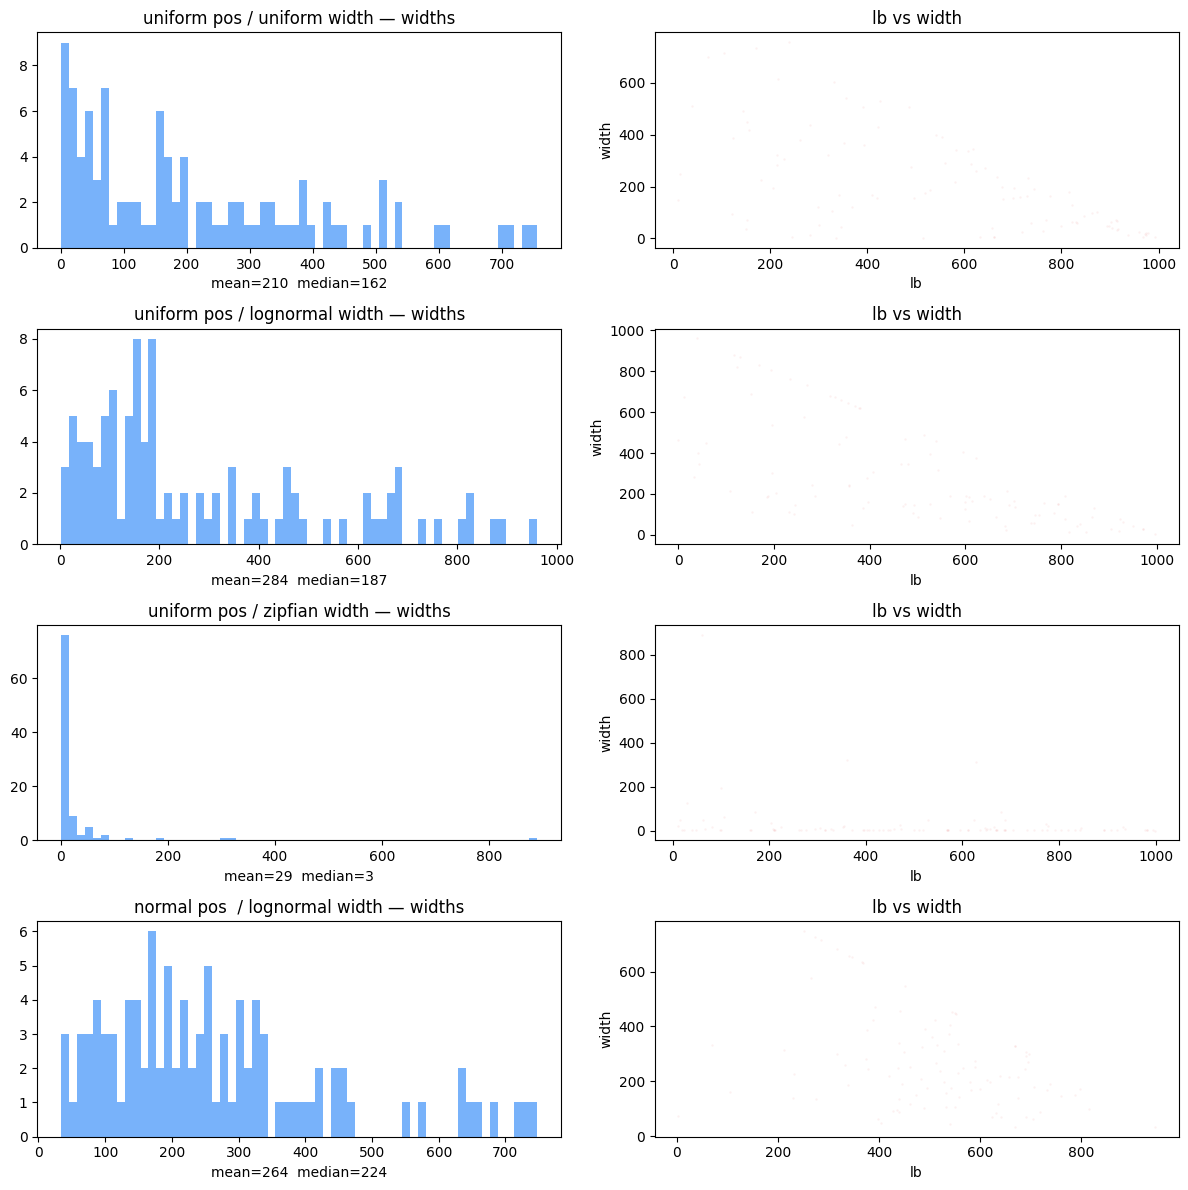

In [84]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(69)
N = 100

def sample(lo, hi, dist="uniform", **kwargs):
    span = max(1, hi - lo)
    i4range = None
    if dist == "uniform":
        # return int(np.random.randint(lo, hi))
        i4range = int(np.random.randint(lo, hi))
    elif dist == "normal":
        mean = kwargs.get("mean", (lo + hi) / 2)
        std  = kwargs.get("std",  span / 6)
        # return int(np.clip(np.random.normal(mean, std), lo, hi - 1))
        i4range = int(np.clip(np.random.normal(mean, std), lo, hi - 1))
    elif dist == "lognormal":
        mean = kwargs.get("mean", np.log((lo + hi) / 2))
        std  = kwargs.get("std",  0.8)
        # return int(np.clip(np.random.lognormal(mean, std), lo, hi - 1))
        i4range =  int(np.clip(np.random.lognormal(mean, std), lo, hi - 1))
    elif dist == "zipfian":
        # return lo + (np.random.zipf(kwargs.get("a", 1.5)) % span)
        i4range = lo + (np.random.zipf(kwargs.get("a", 1.5)) % span)
    elif dist == "exponential":
        # return int(np.clip(np.random.exponential(kwargs.get("scale", span / 4)), lo, hi - 1))
        i4range = int(np.clip(np.random.exponential(kwargs.get("scale", span / 4)), lo, hi - 1))
    
    # print(i4range)
    return i4range

def generate_intervals(n, lo, hi, pos_dist="uniform", width_dist="uniform", **kwargs):
    intervals = []
    for _ in range(n):
        lb    = sample(lo, hi, pos_dist, **kwargs)
        width = sample(1, hi - lb, width_dist, **kwargs)
        intervals.append((lb, lb + width))
    return intervals

# --- try different combos here ---
configs = [
    ("uniform pos / uniform width",   dict(pos_dist="uniform",   width_dist="uniform")),
    ("uniform pos / lognormal width",  dict(pos_dist="uniform",   width_dist="lognormal")),
    ("uniform pos / zipfian width",    dict(pos_dist="uniform",   width_dist="zipfian", a=1.5)),
    ("normal pos  / lognormal width",  dict(pos_dist="normal",    width_dist="lognormal")),
]

fig, axes = plt.subplots(len(configs), 2, figsize=(12, 3 * len(configs)))

for i, (label, cfg) in enumerate(configs):
    intervals = generate_intervals(N, 0, 1000, **cfg)
    lbs    = [lb for lb, _ in intervals]
    widths = [ub - lb for lb, ub in intervals]

    axes[i, 0].hist(widths, bins=60, color="#60a5fa", alpha=0.85)
    axes[i, 0].set_title(f"{label} — widths")
    axes[i, 0].set_xlabel(f"mean={np.mean(widths):.0f}  median={np.median(widths):.0f}")

    axes[i, 1].scatter(lbs, widths, alpha=0.05, s=1, color="#f87171")
    axes[i, 1].set_title("lb vs width")
    axes[i, 1].set_xlabel("lb")
    axes[i, 1].set_ylabel("width")

plt.tight_layout()
plt.show()